# Time Series Analysis of Daily Minimum Temperatures

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [35]:
df = pd.read_csv("../csv2/daily-min-temperatures.csv")
print(df.head(5))

         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8


In [36]:
len(df)

3650

## Dataset Description

The dataset used in this analysis is the **Daily Minimum Temperatures** dataset, obtained from the following public repository:

 https://github.com/jbrownlee/Datasets

The dataset contains daily observations with two variables:

- **Date**: the date of the observation  
- **Temp**: the recorded minimum temperature  

The data spans multiple years and is structured as a univariate time series.

---

## Why this dataset?

This dataset was selected for several reasons:

- It is publicly available and widely used in time series learning contexts.
- It contains a relatively large number of observations (3650), which makes it suitable for statistical modeling.
- The dataset is simple and clean, allowing the analysis to focus on time series methods rather than data preprocessing.
- It represents a real-world time series with natural variability.

---

## Objective of the analysis

The objective of this analysis is to explore the temporal structure of the data and understand its behavior over time.

In particular, the analysis will focus on:

- Visualizing the time series  
- Evaluating stationarity  
- Analyzing autocorrelation patterns (ACF and PACF)  
- Identifying suitable models for time series forecasting  

The goal is to apply classical time series techniques and evaluate their performance on this dataset.

In [37]:
# Shape of the dataset
print("\nShape of the dataset (rows, columns):")
print(df.shape)



Shape of the dataset (rows, columns):
(3650, 2)


In [38]:
# Column names
print("\nColumn names:")
print(df.columns)


Column names:
Index(['Date', 'Temp'], dtype='str')


In [39]:
# Data types and general information
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   str    
 1   Temp    3650 non-null   float64
dtypes: float64(1), str(1)
memory usage: 57.2 KB
None


In [40]:
# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
Date    0
Temp    0
dtype: int64


In [41]:
# Check for duplicated rows
print("\nNumber of duplicated rows:")
print(df.duplicated().sum())



Number of duplicated rows:
0


In [42]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Set Date as index
df.set_index("Date", inplace=True)

# Check again after conversion
print(df.head(5))
print(df.info())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8
<class 'pandas.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB
None


## Exploratory Data Analysis

In this section, we made an exploratory analysis of the daily minimum temperature series.
The goal is to understand the distribution of the data, detect seasonal patterns, and identify
any notable trends across months and years.

In [43]:
# Auxiliary columns for analysis
df["Month"] = df.index.month
df["Year"] = df.index.year
df["Month_name"] = df.index.strftime("%b")

### Descriptive Statistics

The table below summarizes the main statistical characteristics of the temperature variable.
We can observe the central tendency, spread, and shape of the distribution.

In [44]:
print("=== Descriptive Statistics ===")
print(df["Temp"].describe().round(2))
print(f"\nMedian : {df['Temp'].median():.2f}")
print(f"Asimetry (skewness): {df['Temp'].skew():.4f}")
print(f"Curtosis : {df['Temp'].kurtosis():.4f}")

=== Descriptive Statistics ===
count    3650.00
mean       11.18
std         4.07
min         0.00
25%         8.30
50%        11.00
75%        14.00
max        26.30
Name: Temp, dtype: float64

Median : 11.00
Asimetry (skewness): 0.1723
Curtosis : -0.0631


### Temperature Distribution

The histogram below shows the overall distribution of daily minimum temperatures.
The distribution appears  symmetric and bell-shaped, centered around 11–12°C,
which suggests the data is close to normally distributed with no strong skew.
The KDE curve confirms this shape, and the mean and median are very close to each other.

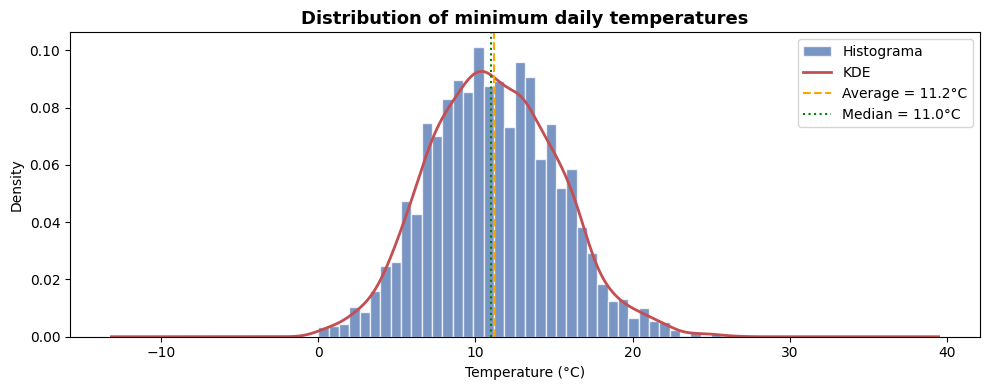

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["Temp"], bins=40, color="#4C72B0", edgecolor="white",
        alpha=0.75, density=True, label="Histograma")
df["Temp"].plot.kde(ax=ax, color="#C44E52", linewidth=2, label="KDE")
ax.axvline(df["Temp"].mean(),   color="orange", linestyle="--", linewidth=1.5,
           label=f"Average = {df['Temp'].mean():.1f}°C")
ax.axvline(df["Temp"].median(), color="green",  linestyle=":",  linewidth=1.5,
           label=f"Median = {df['Temp'].median():.1f}°C")
ax.set_title("Distribution of minimum daily temperatures", fontsize=13, fontweight="bold")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

### Monthly Distribution

The boxplot below displays the temperature distribution for each month of the year.
A clear seasonal pattern is visible: temperatures are higher during the summer months
(December–February in Melbourne's Southern Hemisphere climate) and lower in winter
(June–August). June and July show the lowest medians and the least variability,
while January and December present the highest values.

/tmp/ipykernel_6405/2161322838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Month_name", y="Temp", order=month_order,


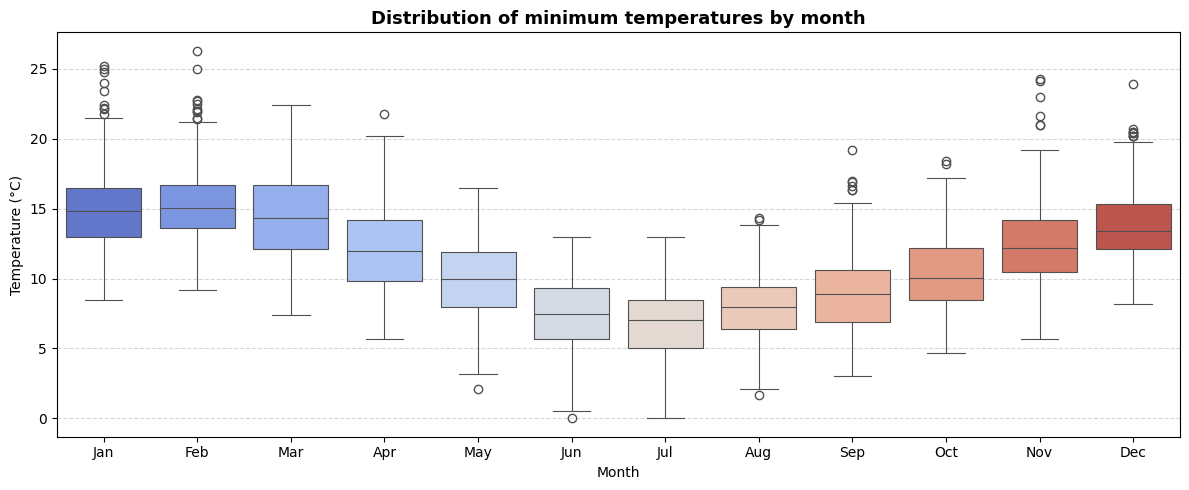

In [46]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="Month_name", y="Temp", order=month_order,
            palette="coolwarm", linewidth=0.8, ax=ax)
ax.set_title("Distribution of minimum temperatures by month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (°C)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Yearly Distribution

The boxplot below shows the temperature distribution for each year in the dataset (1981–1990).
The overall spread and median remain relatively stable across years, suggesting no strong
long-term trend. However, some years such as 1983 and 1988 show  higher variability,
which could reflect anomalous weather events during those periods.

/tmp/ipykernel_6405/3838406918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Year", y="Temp", palette="Blues_d",


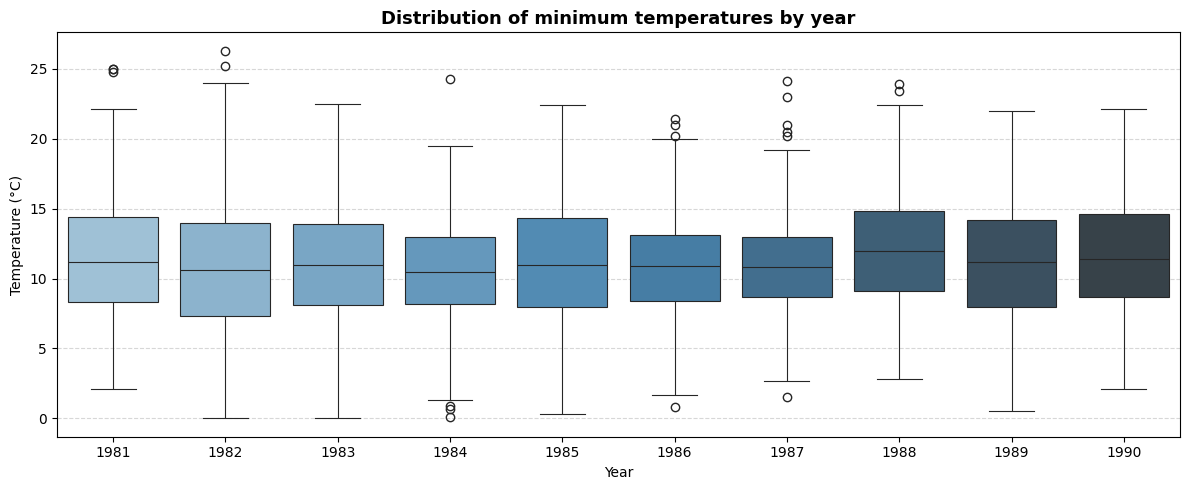

In [47]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="Year", y="Temp", palette="Blues_d",
            linewidth=0.8, ax=ax)
ax.set_title("Distribution of minimum temperatures by year", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Monthly Average Temperature Heatmap

The heatmap provides a compact view of the average minimum temperature for each
month across all years. The seasonal pattern is clearly visible in every row,
with warmer tones in summer months and cooler tones in winter. The consistency
of this pattern across all years reinforces the strong seasonality of the series,
which will be an important factor in the modelling phase.

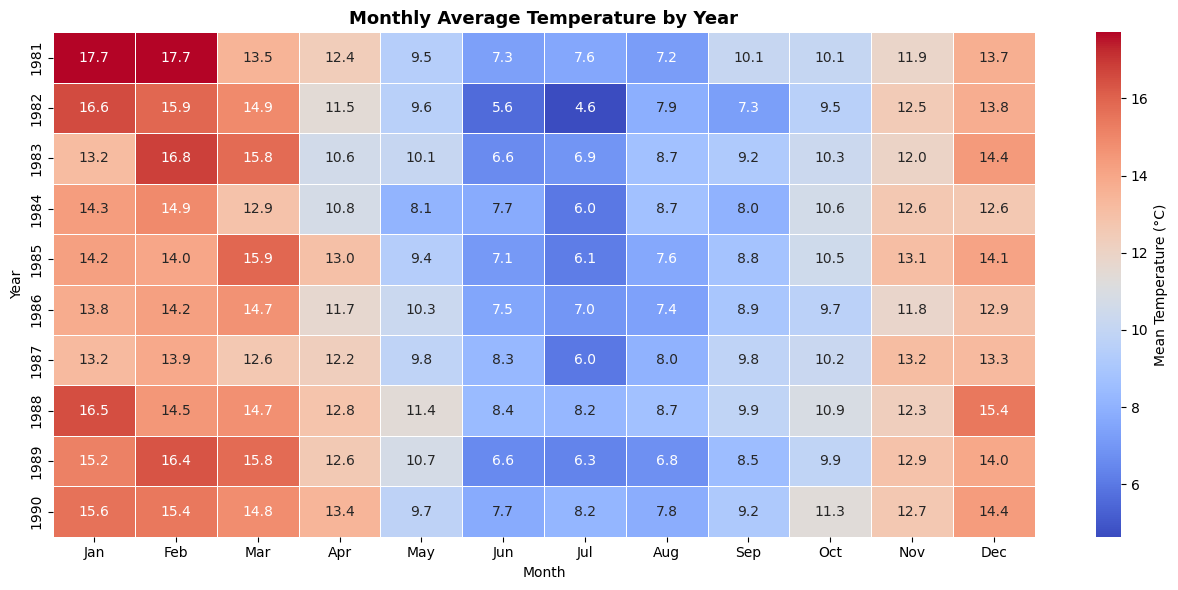

In [48]:
pivot = df.groupby(["Year", "Month"])["Temp"].mean().unstack()
pivot.columns = month_order

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm",
            linewidths=0.4, linecolor="white", ax=ax,
            cbar_kws={"label": "Mean Temperature (°C)"})
ax.set_title("Monthly Average Temperature by Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()